# Predicción de la estancia hospitalaria de pacientes pediátricos peruanos mediante modelos de Machine Learning

**Institución:** Universidad Internacional de La Rioja (UNIR)  
**Programa:** Máster Universitario en Inteligencia Artificial  
**Autora:** Jaci Sandy Torres Torres  
**Director:** Prof. Dr. Raúl Homero Llasag Rosero  
**Dataset:** Instituto Nacional de Salud del Niño San Borja (INSNSB), Lima, Perú. [Disponible aquí ](https://www.datosabiertos.gob.pe/dataset/listado-de-egresos-hospitalarios-enero-diciembre-2025-%E2%80%93-instituto-nacional-de-salud-del-2)

**Metodología:** CRISP-DM

---

## Configuración del entorno

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install xgboost shap --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import unicodedata
import math
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import shap

PALETA = {
    'azul':    '#2C5F8A',
    'verde':   '#3F9B7D',
    'naranja': '#D97D3D',
    'morado':  '#7B5BA6',
    'rojo':    '#C0494A',
    'gris':    '#6B7280',
}

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10.5, 'axes.edgecolor': '#444444',
    'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5,
    'legend.fontsize': 9.5, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
})

SEED = 42
np.random.seed(SEED)

INSNSB_LAT = -12.0964
INSNSB_LON = -76.9822

print('Entorno configurado.')
print(f'pandas={pd.__version__} | xgboost={xgb.__version__} | shap={shap.__version__}')

Entorno configurado.
pandas=2.2.2 | xgboost=3.2.0 | shap=0.52.0


## 1. Carga de datos

In [ ]:
BASE = '/content/drive/MyDrive/DATOS_TESIS/'

df_train_raw = pd.read_csv(BASE + 'Listado_egresos_hospitalarios_ene_dic2025.csv',
                            sep=';', encoding='latin1')

df_ene26 = pd.read_csv(BASE + 'Listado_egresos_hospitalarios_ene_2026.csv',
                        sep=';', encoding='latin1')
df_feb26 = pd.read_csv(BASE + 'Listado_egresos_hospitalarios_feb_2026.csv',
                        sep=';', encoding='latin1')
df_val_raw = pd.concat([df_ene26, df_feb26], ignore_index=True)

ubigeo = pd.read_csv(BASE + 'ubigeo_distrito.csv')

print(f'Entrenamiento (2025) : {df_train_raw.shape[0]:,} registros')
print(f'Validación (2026)    : {df_val_raw.shape[0]:,} registros')
print(f'Ubigeo INEI          : {len(ubigeo):,} distritos')

Entrenamiento (2025) : 5,513 registros
Validación (2026)    : 900 registros
Ubigeo INEI          : 1,893 distritos


### Verificación de calidad de datos

Antes de aplicar cualquier transformación, se examinan los valores nulos por columna en los datos crudos y la posible concentración de múltiples encuentros hospitalarios en un mismo paciente.

In [ ]:
print('Valores nulos por columna — Entrenamiento 2025 (datos crudos):')
nulos = df_train_raw.isnull().sum()
nulos_pct = (nulos / len(df_train_raw) * 100).round(2)
tabla_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': nulos_pct})
print(tabla_nulos[tabla_nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False).to_string())

Valores nulos por columna — Entrenamiento 2025 (datos crudos):
Empty DataFrame
Columns: [Nulos, % Nulos]
Index: []


Verificación de duplicados — Identificador de paciente
Registros totales: 5,513
Pacientes únicos: 4,156
Registros con paciente repetido: 1,357


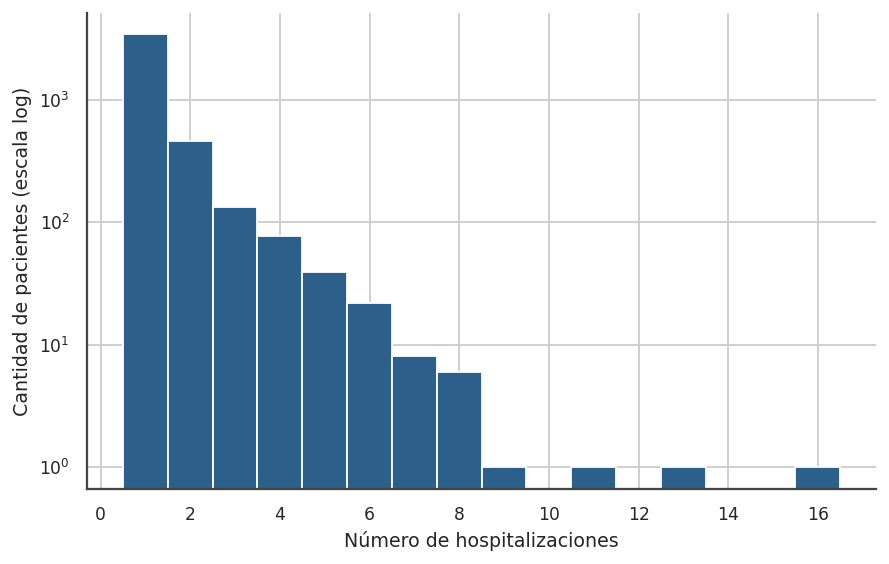

In [ ]:
# Verificación de pacientes duplicados por ID
COL_ID_PACIENTE = 'ID'

print('Verificación de duplicados — Identificador de paciente')
print('=' * 55)
n_pacientes_unicos = df_train_raw[COL_ID_PACIENTE].nunique()
n_registros_repetidos = df_train_raw[COL_ID_PACIENTE].duplicated().sum()
print(f'Registros totales: {len(df_train_raw):,}')
print(f'Pacientes únicos: {n_pacientes_unicos:,}')
print(f'Registros con paciente repetido: {n_registros_repetidos:,}')

encuentros_por_paciente = df_train_raw[COL_ID_PACIENTE].value_counts()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(encuentros_por_paciente, bins=range(1, encuentros_por_paciente.max() + 2),
        color=PALETA['azul'], edgecolor='white', align='left')
#ax.set_title('Pacientes según cantidad de encuentros hospitalarios')
ax.set_xlabel('Número de hospitalizaciones'); ax.set_ylabel('Cantidad de pacientes (escala log)')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('/content/fig1_encuentros_pacientes.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
print(encuentros_por_paciente.value_counts().sort_index())

count
1     3407
2      461
3      132
4       77
5       39
6       22
7        8
8        6
9        1
11       1
13       1
16       1
Name: count, dtype: int64


## 2. Preparación de datos

In [ ]:
def normalizar_texto(s):
    if pd.isna(s): return s
    s = str(s).upper().strip()
    s = unicodedata.normalize('NFKD', s)
    return ''.join(c for c in s if not unicodedata.combining(c))

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi    = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return round(R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a)), 2)

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


In [ ]:
ubigeo_merge = ubigeo[[
    'distrito', 'provincia', 'departamento',
    'latitude', 'longitude', 'altitude', 'macroregion_inei'
]].copy()
ubigeo_merge['distrito_norm']  = ubigeo_merge['distrito'].apply(normalizar_texto)
ubigeo_merge['provincia_norm'] = ubigeo_merge['provincia'].apply(normalizar_texto)
ubigeo_merge.drop_duplicates(subset=['distrito_norm','provincia_norm'], keep='first', inplace=True)

print(f'Ubigeo preparado: {len(ubigeo_merge):,} pares distrito-provincia únicos.')

Ubigeo preparado: 1,893 pares distrito-provincia únicos.


In [ ]:
df_temp = df_train_raw.copy()
df_temp['FECHA_INGRESO'] = pd.to_datetime(df_temp['FECHA_INGRESO'], format='%d/%m/%Y', errors='coerce')
df_temp['FECHA_EGRESO']  = pd.to_datetime(df_temp['FECHA_EGRESO'],  format='%d/%m/%Y', errors='coerce')
df_temp['ESTANCIA_DIAS'] = (df_temp['FECHA_EGRESO'] - df_temp['FECHA_INGRESO']).dt.days
df_temp = df_temp[df_temp['ESTANCIA_DIAS'] >= 0]

Q1, Q3 = df_temp['ESTANCIA_DIAS'].quantile([0.25, 0.75])
IQR = Q3 - Q1
LIMITE_TUKEY = Q3 + 1.5 * IQR

print(f'Q1 = {Q1:.0f} d | Q3 = {Q3:.0f} d | IQR = {IQR:.0f} d')
print(f'Límite Tukey = {LIMITE_TUKEY:.0f} días')

Q1 = 5 d | Q3 = 20 d | IQR = 15 d
Límite Tukey = 42 días


### Justificación de uso de criterio Tukey

A continuación se muestra la distribución completa de la estancia hospitalaria en días.

In [ ]:
n_total = len(df_temp)
n_outliers = (df_temp['ESTANCIA_DIAS'] > LIMITE_TUKEY).sum()
pct_outliers = n_outliers / n_total * 100

print('Estancia hospitalaria — datos sin filtrar (Entrenamiento 2025)')
print(df_temp['ESTANCIA_DIAS'].describe().round(2).to_string())
print()
print(f'Registros que superan el límite de Tukey ({LIMITE_TUKEY:.0f} días): '
      f'{n_outliers:,} de {n_total:,} ({pct_outliers:.1f}%)')

Estancia hospitalaria — datos sin filtrar (Entrenamiento 2025)
count    5513.00
mean       17.29
std        22.24
min         0.00
25%         5.00
50%         9.00
75%        20.00
max       181.00

Registros que superan el límite de Tukey (42 días): 556 de 5,513 (10.1%)


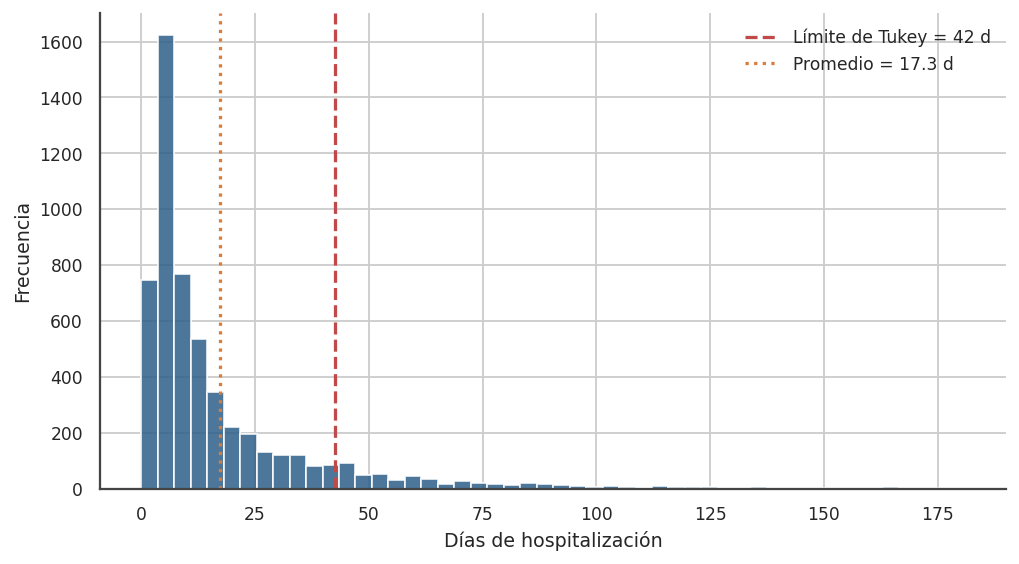

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df_temp['ESTANCIA_DIAS'], bins=50, color=PALETA['azul'], edgecolor='white', alpha=0.85)
ax.axvline(LIMITE_TUKEY, color=PALETA['rojo'], linestyle='--', linewidth=1.8,
           label=f'Límite de Tukey = {LIMITE_TUKEY:.0f} d')
ax.axvline(df_temp['ESTANCIA_DIAS'].mean(), color=PALETA['naranja'], linestyle=':', linewidth=1.8,
           label=f"Promedio = {df_temp['ESTANCIA_DIAS'].mean():.1f} d")
#ax.set_title('Distribución de la estancia hospitalaria sin filtrar (cola larga)')
ax.set_xlabel('Días de hospitalización'); ax.set_ylabel('Frecuencia')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('/content/fig2_tukey_corte.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
def preprocesar(df, ubigeo_df, nombre='dataset', limite=None):
    df = df.copy()
    if 'FECHA_CORTE' in df.columns:
        df.drop(columns=['FECHA_CORTE'], inplace=True)

    df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'], format='%d/%m/%Y', errors='coerce')
    df['FECHA_EGRESO']  = pd.to_datetime(df['FECHA_EGRESO'],  format='%d/%m/%Y', errors='coerce')
    df['ESTANCIA_DIAS'] = (df['FECHA_EGRESO'] - df['FECHA_INGRESO']).dt.days

    n0 = len(df)
    df = df[df['ESTANCIA_DIAS'] >= 0].copy()
    if len(df) < n0:
        print(f'  [{nombre}] Registros con estancia inválida eliminados: {n0 - len(df)}')

    if limite is not None:
        n1 = len(df)
        df = df[df['ESTANCIA_DIAS'] <= limite].copy()
        print(f'  [{nombre}] Outliers filtrados (> {limite:.0f} días): {n1 - len(df)} registros')

    df['SEXO']      = df['SEXO'].str.strip().str.upper()
    df['TIPO_EDAD'] = df['TIPO_EDAD'].str.strip().str.upper()
    factor = {'ANOS': 365, 'AÑOS': 365, 'MES': 30, 'DIAS': 1, 'HORAS': 1/24}
    df['EDAD_DIAS'] = df.apply(lambda r: r['EDAD'] * factor.get(r['TIPO_EDAD'], 365), axis=1).round(1)

    bins   = [0, 28, 365, 365*2, 365*5, 365*10, 365*18, np.inf]
    labels = ['Neonato','Lactante','1-2a','2-5a','5-10a','10-18a','>=18a']
    df['GRUPO_ETARIO'] = pd.cut(df['EDAD_DIAS'], bins=bins, labels=labels, right=False)
    grupo_orden = {'Neonato':0,'Lactante':1,'1-2a':2,'2-5a':3,'5-10a':4,'10-18a':5,'>=18a':6}
    df['GRUPO_ETARIO_COD'] = df['GRUPO_ETARIO'].map(grupo_orden).fillna(3).astype(int)

    for et in labels:
        df[f'ETARIO_{et}'] = (df['GRUPO_ETARIO'] == et).astype(int)

    df['MES_INGRESO']      = df['FECHA_INGRESO'].dt.month
    df['DIA_SEMANA_ING']   = df['FECHA_INGRESO'].dt.dayofweek
    df['ES_FIN_DE_SEMANA'] = (df['DIA_SEMANA_ING'] >= 5).astype(int)
    df['TRIMESTRE_ING']    = df['FECHA_INGRESO'].dt.quarter

    partes = df['PROCEDENCIA'].str.split('-', expand=True)
    df['REGION']    = partes[0].apply(normalizar_texto)
    df['PROVINCIA'] = partes[1].apply(normalizar_texto) if partes.shape[1] > 1 else 'DESCONOCIDO'
    df['DISTRITO']  = partes[2].apply(normalizar_texto) if partes.shape[1] > 2 else 'DESCONOCIDO'
    df['ES_LIMA']   = (df['REGION'] == 'LIMA').astype(int)
    df['SEXO_BIN']  = (df['SEXO'] == 'MASCULINO').astype(int)

    df = df.merge(ubigeo_df[['distrito_norm','provincia_norm','latitude','longitude',
                              'altitude','macroregion_inei']],
                  left_on=['DISTRITO','PROVINCIA'], right_on=['distrito_norm','provincia_norm'],
                  how='left')

    macro_orden = {'LIMA METROPOLITANA':0,'CENTRO':1,'NORTE':2,'SUR':3,'ORIENTE':4}
    df['MACROREGION_COD'] = df['macroregion_inei'].map(macro_orden).fillna(1).astype(int)
    for mr in macro_orden:
        col = 'MACRO_' + mr.replace(' ', '_')
        df[col] = (df['macroregion_inei'] == mr).astype(int)

    df['DISTANCIA_KM'] = df.apply(
        lambda r: haversine_km(r['latitude'], r['longitude'], INSNSB_LAT, INSNSB_LON)
        if pd.notna(r['latitude']) else np.nan, axis=1)
    df['DISTANCIA_KM'] = df['DISTANCIA_KM'].fillna(df['DISTANCIA_KM'].median())
    df['altitude']     = df['altitude'].fillna(df['altitude'].median())

    # Categorización por cuartiles — captura efectos de umbral, no solo lineales
    df['DISTANCIA_CUARTIL'] = pd.qcut(df['DISTANCIA_KM'], 4, labels=[0,1,2,3], duplicates='drop').astype(int)
    df['ALTITUD_CUARTIL']   = pd.qcut(df['altitude'].rank(method='first'), 4, labels=[0,1,2,3]).astype(int)
    df['ZONA_ALTOANDINA']   = (df['altitude'] >= 2500).astype(int)

    n_geo = df['latitude'].notna().sum()
    print(f'  [{nombre}] Cruce geográfico exitoso: {n_geo:,}/{len(df):,} ({n_geo/len(df)*100:.1f}%)')
    print(f'  [{nombre}] Shape final: {df.shape}')
    return df

print('Función preprocesar() definida.')

Función preprocesar() definida.


In [ ]:
df_train = preprocesar(df_train_raw, ubigeo_merge, 'ENTRENAMIENTO 2025', limite=LIMITE_TUKEY)
print()
df_val   = preprocesar(df_val_raw, ubigeo_merge, 'VALIDACIÓN 2026', limite=LIMITE_TUKEY)
print()
print('Estancia — entrenamiento filtrado:')
print(df_train['ESTANCIA_DIAS'].describe().round(2).to_string())
print()
print('Estancia — validación filtrada:')
print(df_val['ESTANCIA_DIAS'].describe().round(2).to_string())

  [ENTRENAMIENTO 2025] Outliers filtrados (> 42 días): 556 registros
  [ENTRENAMIENTO 2025] Cruce geográfico exitoso: 4,851/4,957 (97.9%)
  [ENTRENAMIENTO 2025] Shape final: (4957, 43)

  [VALIDACIÓN 2026] Outliers filtrados (> 42 días): 84 registros
  [VALIDACIÓN 2026] Cruce geográfico exitoso: 811/816 (99.4%)
  [VALIDACIÓN 2026] Shape final: (816, 43)

Estancia — entrenamiento filtrado:
count    4957.00
mean       11.25
std         9.43
min         0.00
25%         5.00
50%         8.00
75%        15.00
max        42.00

Estancia — validación filtrada:
count    816.00
mean      10.75
std        9.33
min        0.00
25%        5.00
50%        7.00
75%       14.00
max       42.00


## 3. Análisis exploratorio

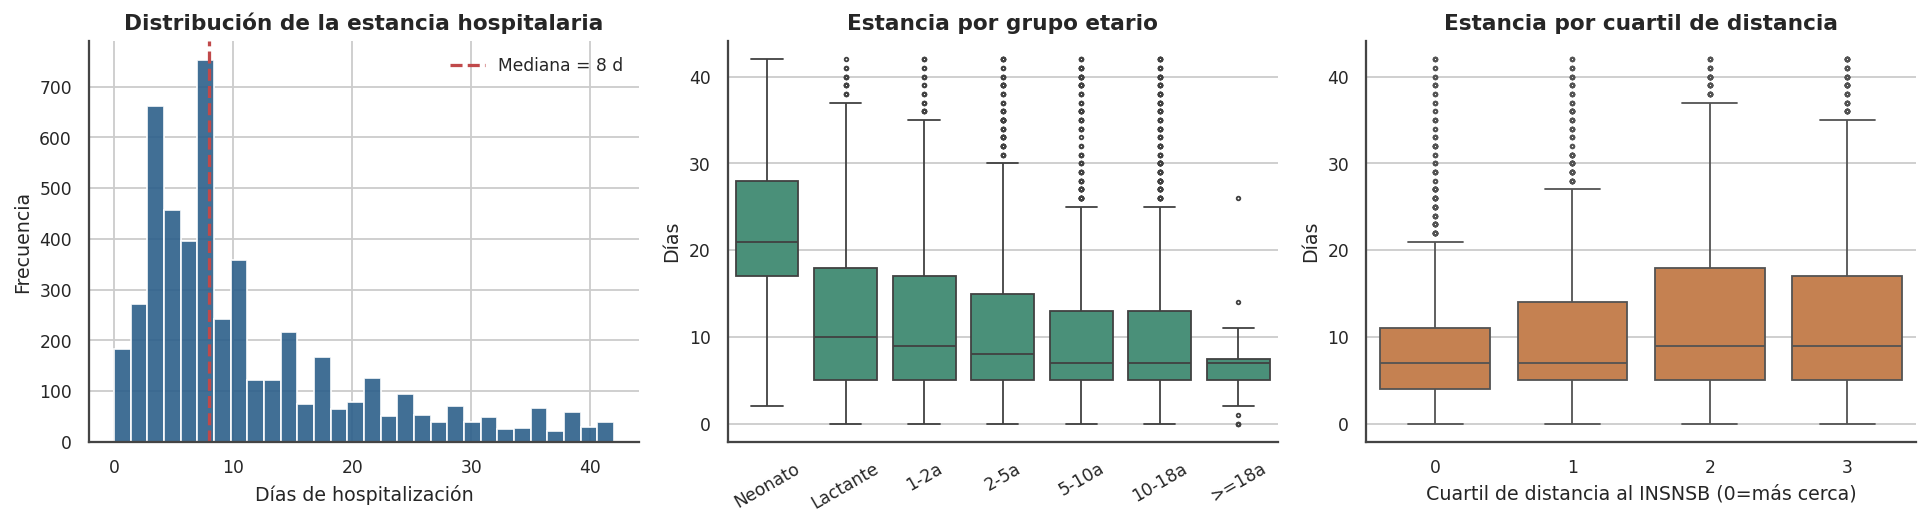

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
ax.hist(df_train['ESTANCIA_DIAS'], bins=30, color=PALETA['azul'], edgecolor='white', alpha=0.9)
ax.axvline(df_train['ESTANCIA_DIAS'].median(), color=PALETA['rojo'], linestyle='--', linewidth=1.8,
           label=f"Mediana = {df_train['ESTANCIA_DIAS'].median():.0f} d")
ax.set_title('Distribución de la estancia hospitalaria')
ax.set_xlabel('Días de hospitalización'); ax.set_ylabel('Frecuencia')
ax.legend(frameon=False)

orden_g = ['Neonato','Lactante','1-2a','2-5a','5-10a','10-18a','>=18a']
d_box = df_train.copy()
d_box['GRUPO_ETARIO'] = pd.Categorical(d_box['GRUPO_ETARIO'], categories=orden_g, ordered=True)
sns.boxplot(data=d_box, x='GRUPO_ETARIO', y='ESTANCIA_DIAS', ax=axes[1],
            color=PALETA['verde'], fliersize=2, linewidth=1)
axes[1].set_title('Estancia por grupo etario')
axes[1].set_xlabel(''); axes[1].set_ylabel('Días'); axes[1].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_train, x='DISTANCIA_CUARTIL', y='ESTANCIA_DIAS', ax=axes[2],
            color=PALETA['naranja'], fliersize=2, linewidth=1)
axes[2].set_title('Estancia por cuartil de distancia')
axes[2].set_xlabel('Cuartil de distancia al INSNSB (0=más cerca)'); axes[2].set_ylabel('Días')

plt.tight_layout()
plt.savefig('/content/fig3_eda.png', bbox_inches='tight', dpi=150)
plt.show()

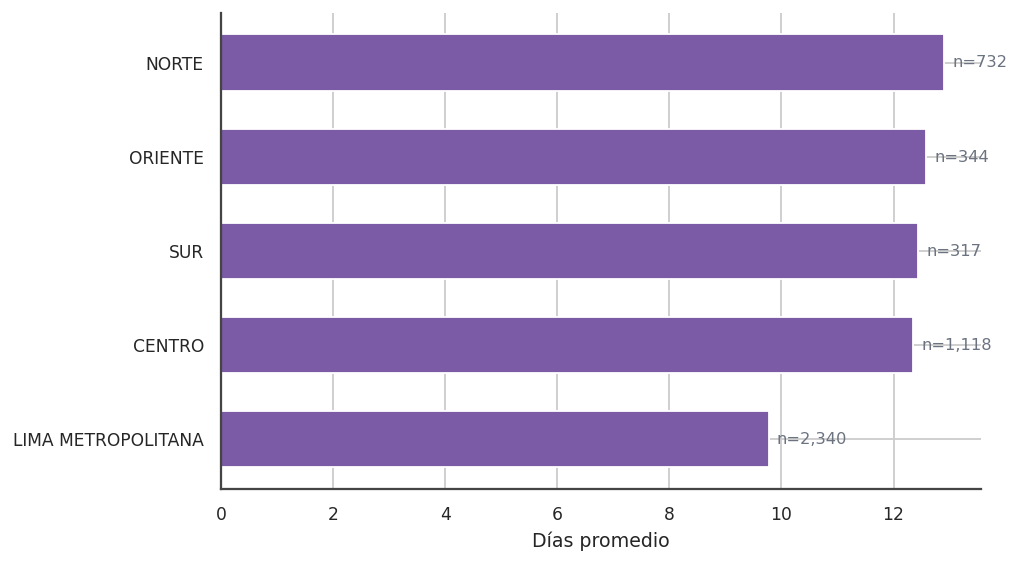

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
medias_macro = df_train.groupby('macroregion_inei')['ESTANCIA_DIAS'].agg(['mean','count']).reset_index()
medias_macro = medias_macro.sort_values('mean', ascending=True)

bars = ax.barh(medias_macro['macroregion_inei'], medias_macro['mean'],
               color=PALETA['morado'], edgecolor='white', height=0.6)
for bar, n in zip(bars, medias_macro['count']):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f"n={n:,}", va='center', fontsize=9, color=PALETA['gris'])

#ax.set_title('Estancia promedio por macrorregión de procedencia')
ax.set_xlabel('Días promedio')
plt.tight_layout()
plt.savefig('/content/fig4_macroregion.png', bbox_inches='tight', dpi=150)
plt.show()

### Relaciones entre variables numéricas

Se complementa el análisis exploratorio con una tabla descriptiva ampliada (incluyendo el coeficiente de asimetría, que evidencia numéricamente la cola larga de la estancia hospitalaria), una matriz de correlación entre las variables numéricas candidatas y la distribución de las variables categóricas principales.

In [ ]:
from scipy.stats import skew

tabla_descriptiva = df_train[['ESTANCIA_DIAS', 'EDAD_DIAS', 'DISTANCIA_KM', 'altitude']].describe().T
tabla_descriptiva = tabla_descriptiva[['min', '25%', '50%', 'mean', '75%', 'max', 'std']].round(2)
tabla_descriptiva.columns = ['Mínimo', 'Q1', 'Mediana', 'Promedio', 'Q3', 'Máximo', 'Desv. Estándar']

tabla_descriptiva['Asimetría'] = [
    round(skew(df_train[col].dropna()), 2)
    for col in ['ESTANCIA_DIAS', 'EDAD_DIAS', 'DISTANCIA_KM', 'altitude']
]

print('Estadística descriptiva ampliada — variables numéricas (Entrenamiento 2025)')
print(tabla_descriptiva)

Estadística descriptiva ampliada — variables numéricas (Entrenamiento 2025)
               Mínimo      Q1  Mediana  Promedio       Q3   Máximo  \
ESTANCIA_DIAS    0.00    5.00     8.00     11.25    15.00     42.0   
EDAD_DIAS        0.80  730.00  2190.00   2542.71  4015.00  17885.0   
DISTANCIA_KM     2.18   10.21    71.18    257.06   492.28   1049.0   
altitude         5.00  107.00   210.00    754.77   689.00   4394.0   

               Desv. Estándar  Asimetría  
ESTANCIA_DIAS            9.43       1.41  
EDAD_DIAS             2023.51       1.09  
DISTANCIA_KM           306.54       0.97  
altitude              1128.73       1.65  


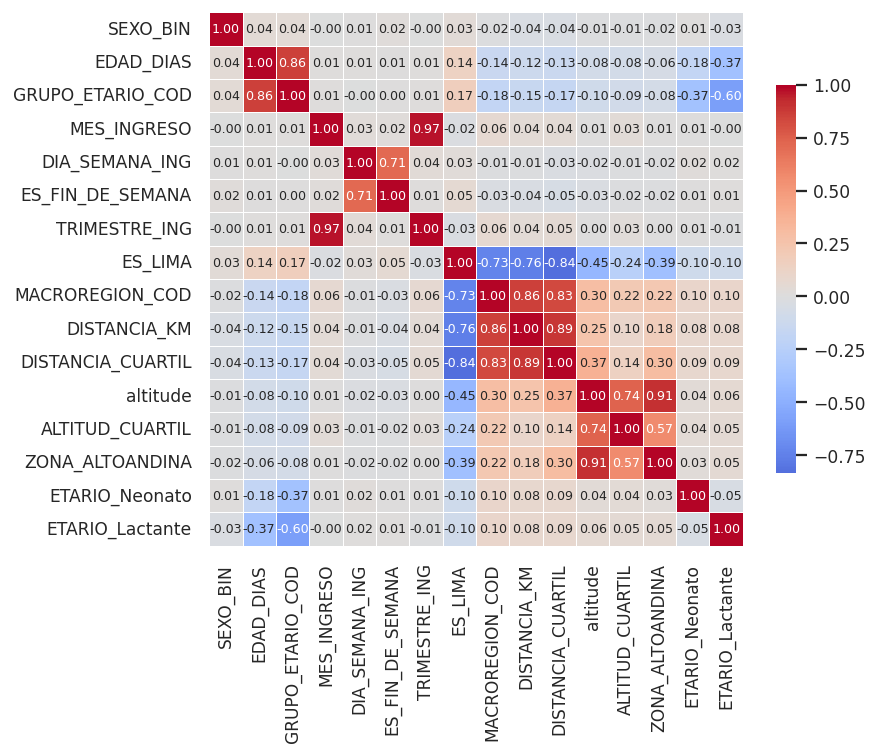

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
vars_corr = ['SEXO_BIN', 'EDAD_DIAS', 'GRUPO_ETARIO_COD',
    'MES_INGRESO', 'DIA_SEMANA_ING', 'ES_FIN_DE_SEMANA', 'TRIMESTRE_ING',
    'ES_LIMA', 'MACROREGION_COD', 'DISTANCIA_KM', 'DISTANCIA_CUARTIL',
    'altitude', 'ALTITUD_CUARTIL', 'ZONA_ALTOANDINA',
    'ETARIO_Neonato', 'ETARIO_Lactante',]
corr_matrix = df_train[vars_corr].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7}, annot_kws={'size': 7})
plt.tight_layout()
plt.savefig('/content/fig5_correlacion.png', bbox_inches='tight', dpi=150)
plt.show()

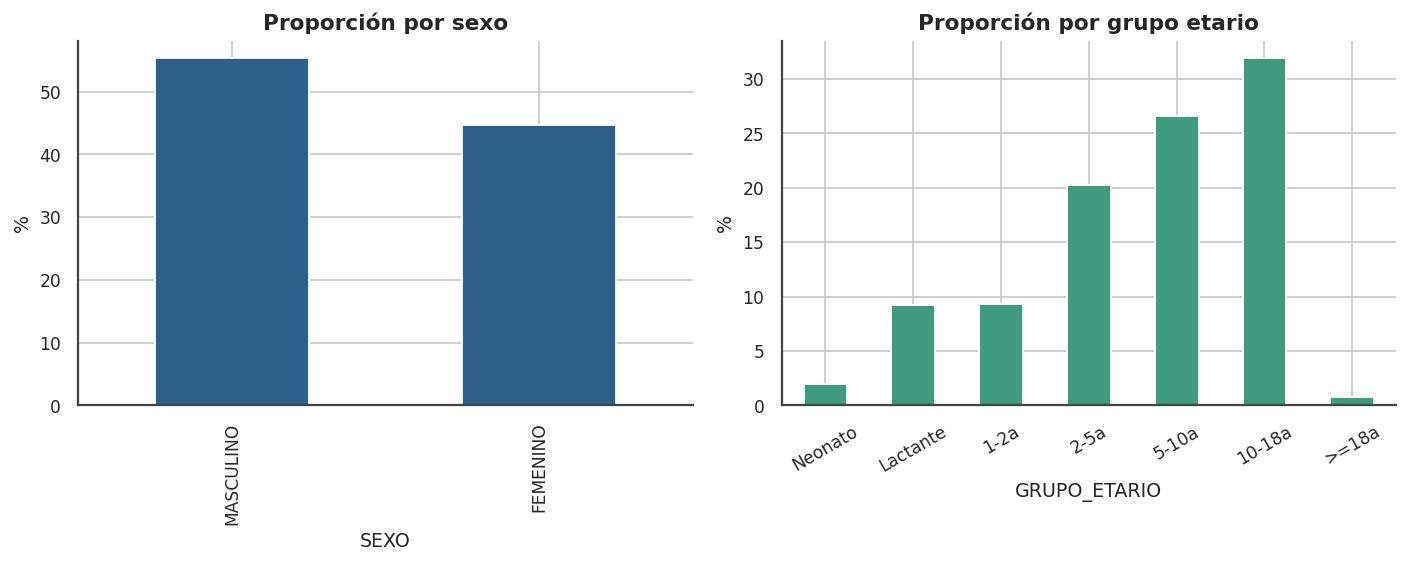

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

df_train['SEXO'].value_counts(normalize=True).mul(100).plot(
    kind='bar', ax=axes[0], color=PALETA['azul'], edgecolor='white')
axes[0].set_title('Proporción por sexo'); axes[0].set_ylabel('%')

orden_g = ['Neonato', 'Lactante', '1-2a', '2-5a', '5-10a', '10-18a', '>=18a']
df_train['GRUPO_ETARIO'].value_counts(normalize=True).mul(100).reindex(orden_g).plot(
    kind='bar', ax=axes[1], color=PALETA['verde'], edgecolor='white')
axes[1].set_title('Proporción por grupo etario'); axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/fig6_proporciones.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Selección de variables mediante SHAP

Se amplía el conjunto de variables candidatas respecto a la versión principal, incluyendo tanto las versiones continuas como categorizadas de edad, distancia y altitud, y dummies de grupo etario y macrorregión. El modelo selecciona las variables, mediante SHAP, qué variables son importantes, evitando imponer a priori que la relación es lineal u ordinal.

In [ ]:
FEATURES_CANDIDATOS = [
    'SEXO_BIN', 'EDAD_DIAS', 'GRUPO_ETARIO_COD',
    'MES_INGRESO', 'DIA_SEMANA_ING', 'ES_FIN_DE_SEMANA', 'TRIMESTRE_ING',
    'ES_LIMA', 'MACROREGION_COD', 'DISTANCIA_KM', 'DISTANCIA_CUARTIL',
    'altitude', 'ALTITUD_CUARTIL', 'ZONA_ALTOANDINA',
    'ETARIO_Neonato', 'ETARIO_Lactante',
]

FEATURES_CANDIDATOS = [f for f in FEATURES_CANDIDATOS if f in df_train.columns]

X_cand_train = df_train[FEATURES_CANDIDATOS].values
X_cand_val   = df_val[FEATURES_CANDIDATOS].values
y_train      = df_train['ESTANCIA_DIAS'].values.astype(float)
y_val        = df_val['ESTANCIA_DIAS'].values.astype(float)

rf_exploratorio = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=SEED, n_jobs=-1)
rf_exploratorio.fit(X_cand_train, y_train)

explainer = shap.TreeExplainer(rf_exploratorio)
shap_vals = explainer.shap_values(X_cand_val)

imp_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=FEATURES_CANDIDATOS).sort_values(ascending=False)

UMBRAL_SHAP = 0.10
FEATURES = imp_shap[imp_shap >= UMBRAL_SHAP].index.tolist()

print(f'Variables candidatas: {len(FEATURES_CANDIDATOS)}')
print('Variables seleccionadas (≥ umbral):')
for var, val in imp_shap[imp_shap >= UMBRAL_SHAP].items():
    print(f'  {var:<22} {val:.4f} d')
print()
print('Variables descartadas (< umbral):')
for var, val in imp_shap[imp_shap < UMBRAL_SHAP].items():
    print(f'  {var:<22} {val:.4f} d')

Variables candidatas: 16
Variables seleccionadas (≥ umbral):
  DISTANCIA_KM           0.9858 d
  EDAD_DIAS              0.9217 d
  ES_LIMA                0.4434 d
  altitude               0.4431 d
  MES_INGRESO            0.3739 d
  DIA_SEMANA_ING         0.3039 d
  SEXO_BIN               0.2267 d
  GRUPO_ETARIO_COD       0.1038 d

Variables descartadas (< umbral):
  MACROREGION_COD        0.0815 d
  ALTITUD_CUARTIL        0.0815 d
  TRIMESTRE_ING          0.0782 d
  ES_FIN_DE_SEMANA       0.0681 d
  DISTANCIA_CUARTIL      0.0565 d
  ETARIO_Lactante        0.0100 d
  ZONA_ALTOANDINA        0.0060 d
  ETARIO_Neonato         0.0009 d


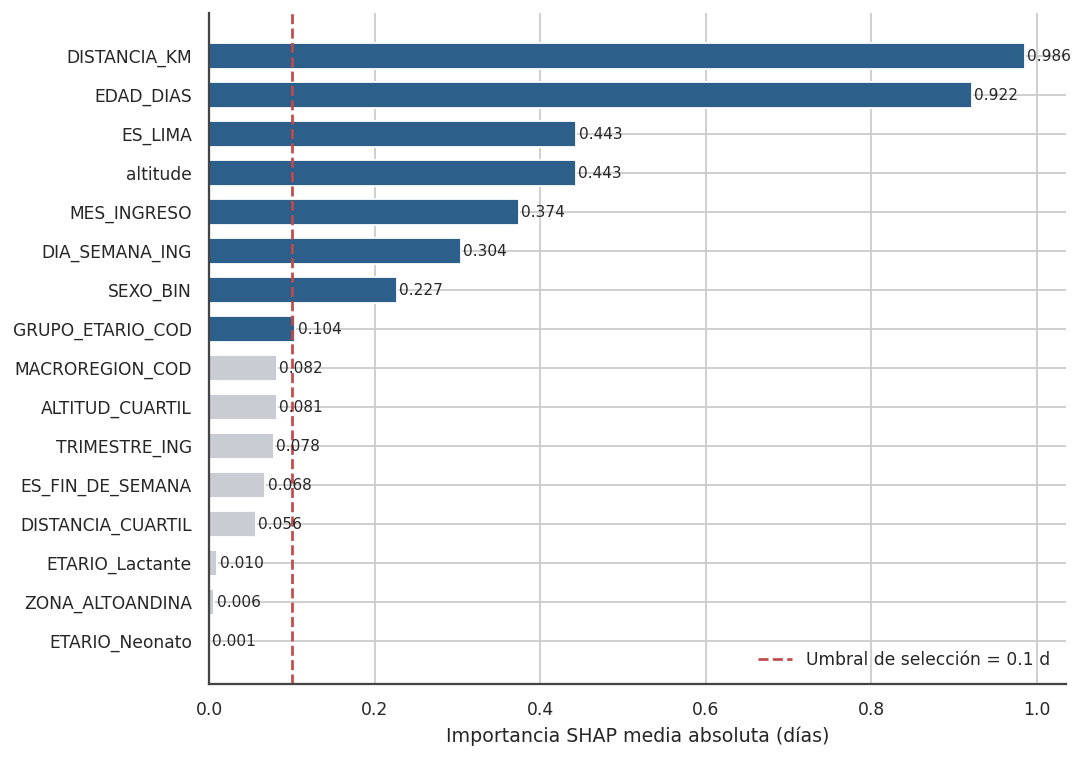

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6))
colores_bar = [PALETA['azul'] if v >= UMBRAL_SHAP else '#C9CDD3' for v in imp_shap.values]
bars = ax.barh(imp_shap.index[::-1], imp_shap.values[::-1], color=colores_bar[::-1], edgecolor='white', height=0.65)
ax.axvline(UMBRAL_SHAP, color=PALETA['rojo'], linestyle='--', linewidth=1.5,
           label=f'Umbral de selección = {UMBRAL_SHAP} d')
ax.set_xlabel('Importancia SHAP media absoluta (días)')
ax.legend(frameon=False, loc='lower right')
for bar, val in zip(bars, imp_shap.values[::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('/content/fig7_shap.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
X_train_raw = df_train[FEATURES].values
X_val_raw   = df_val[FEATURES].values

scaler_std = StandardScaler()
X_train_sc = scaler_std.fit_transform(X_train_raw)
X_val_sc   = scaler_std.transform(X_val_raw)

scaler_rob = RobustScaler()
X_train_rb = scaler_rob.fit_transform(X_train_raw)
X_val_rb   = scaler_rob.transform(X_val_raw)

X_train = X_train_raw.copy()
X_val   = X_val_raw.copy()

print(f'Variables finales seleccionadas: {FEATURES}')
print(f'X_train: {X_train.shape} | X_val: {X_val.shape}')

Variables finales seleccionadas: ['DISTANCIA_KM', 'EDAD_DIAS', 'ES_LIMA', 'altitude', 'MES_INGRESO', 'DIA_SEMANA_ING', 'SEXO_BIN', 'GRUPO_ETARIO_COD']
X_train: (4957, 8) | X_val: (816, 8)


## 5. Modelado

Se entrenan los cuatro modelos con espacios de búsqueda ampliados respecto a la versión principal, incorporando parámetros de regularización adicionales recomendados por Bentéjac et al. (2021) para XGBoost, y un tratamiento diferenciado para SVR con escalado robusto (Bhoopathi et al., 2024).

### 5.1 Regresión Lineal

In [ ]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr_train = lr.predict(X_train_sc)
y_pred_lr_val   = lr.predict(X_val_sc)
print('Regresión lineal entrenada.')

coeficientes_lr = pd.Series(lr.coef_, index=FEATURES).sort_values(key=abs, ascending=False)
print('Coeficientes de la Regresión Lineal (variables estandarizadas):')
print(coeficientes_lr.round(3).to_string())
print(f'\nIntercepto: {lr.intercept_:.3f}')

Regresión lineal entrenada.
Coeficientes de la Regresión Lineal (variables estandarizadas):
GRUPO_ETARIO_COD   -1.530
ES_LIMA            -0.774
EDAD_DIAS           0.493
altitude            0.434
DIA_SEMANA_ING      0.343
DISTANCIA_KM        0.274
SEXO_BIN           -0.218
MES_INGRESO         0.186

Intercepto: 11.247


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Variable'] = FEATURES
vif_data['VIF'] = [variance_inflation_factor(X_train_sc, i) for i in range(len(FEATURES))]
print('Factor de Inflación de Varianza (VIF) — variables del modelo final:')
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

Factor de Inflación de Varianza (VIF) — variables del modelo final:
        Variable      VIF
GRUPO_ETARIO_COD 3.957458
       EDAD_DIAS 3.911773
         ES_LIMA 2.888685
    DISTANCIA_KM 2.460897
        altitude 1.280046
        SEXO_BIN 1.003202
     MES_INGRESO 1.003002
  DIA_SEMANA_ING 1.002587


### 5.2 Random Forest

In [ ]:
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_distributions={
        'n_estimators':      [200, 300, 500, 800],
        'max_depth':         [None, 6, 10, 15, 20],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf':  [1, 2, 4, 8],
        'max_features':      ['sqrt', 'log2', 0.5, 0.7],
    },
    n_iter=60, cv=5, scoring='neg_root_mean_squared_error',
    random_state=SEED, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)
rf = rf_search.best_estimator_

y_pred_rf_train = rf.predict(X_train)
y_pred_rf_val   = rf.predict(X_val)

print(f'Mejores hiperparámetros RF: {rf_search.best_params_}')
print(f'RMSE CV: {-rf_search.best_score_:.4f} días')

Mejores hiperparámetros RF: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 6}
RMSE CV: 9.7029 días


### 5.3 XGBoost

In [ ]:
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0),
    param_distributions={
        'n_estimators':     [150, 300, 500],
        'max_depth':        [3, 4, 5, 6, 7],
        'learning_rate':    [0.01, 0.03, 0.05, 0.1],
        'subsample':        [0.6, 0.7, 0.8, 1.0],
        'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
        'reg_lambda':       [1, 3, 5, 10, 20],
        'reg_alpha':        [0, 0.1, 0.5, 1.0],
        'min_child_weight': [1, 3, 5, 10],
        'gamma':            [0, 0.1, 0.3, 0.5],
    },
    n_iter=80, cv=5, scoring='neg_root_mean_squared_error',
    random_state=SEED, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
xgb_model = xgb_search.best_estimator_

y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_val   = xgb_model.predict(X_val)

print(f'Mejores hiperparámetros XGB: {xgb_search.best_params_}')
print(f'RMSE CV: {-xgb_search.best_score_:.4f} días')

Mejores hiperparámetros XGB: {'subsample': 0.7, 'reg_lambda': 20, 'reg_alpha': 1.0, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.5}
RMSE CV: 9.5582 días


### 5.4 SVR

In [ ]:
svr_search = RandomizedSearchCV(
    SVR(),
    param_distributions={
        'kernel':  ['rbf', 'linear', 'poly'],
        'C':       [0.5, 1, 5, 10, 30, 50, 100, 200],
        'epsilon': [0.05, 0.1, 0.3, 0.5, 0.8, 1.0],
        'gamma':   ['scale', 'auto', 0.01, 0.05, 0.1],
        'degree':  [2, 3],
    },
    n_iter=60, cv=5, scoring='neg_root_mean_squared_error',
    random_state=SEED, n_jobs=-1, verbose=0
)
svr_search.fit(X_train_rb, y_train)
svr = svr_search.best_estimator_

y_pred_svr_train = svr.predict(X_train_rb)
y_pred_svr_val   = svr.predict(X_val_rb)

print(f'Mejores hiperparámetros SVR: {svr_search.best_params_}')
print(f'RMSE CV: {-svr_search.best_score_:.4f} días')
print(f'Std predicciones SVR (val): {y_pred_svr_val.std():.2f} d  |  Std real: {y_val.std():.2f} d')

Mejores hiperparámetros SVR: {'kernel': 'rbf', 'gamma': 0.05, 'epsilon': 1.0, 'degree': 3, 'C': 30}
RMSE CV: 9.6520 días
Std predicciones SVR (val): 2.11 d  |  Std real: 9.32 d


## 6. Evaluación de modelos

In [ ]:
def metricas_reg(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R²': round(r2, 4)}

preds_train = {
    'Regresión Lineal': y_pred_lr_train, 'Random Forest': y_pred_rf_train,
    'XGBoost': y_pred_xgb_train, 'SVR': y_pred_svr_train,
}
preds_val = {
    'Regresión Lineal': y_pred_lr_val, 'Random Forest': y_pred_rf_val,
    'XGBoost': y_pred_xgb_val, 'SVR': y_pred_svr_val,
}

res_train = {m: metricas_reg(y_train, p) for m, p in preds_train.items()}
res_val   = {m: metricas_reg(y_val, p) for m, p in preds_val.items()}

df_res_train = pd.DataFrame([{'Modelo': m, **v} for m, v in res_train.items()]).set_index('Modelo')
df_res_val   = pd.DataFrame([{'Modelo': m, **v} for m, v in res_val.items()]).set_index('Modelo')

print('Métricas — Entrenamiento 2025 (filtrado ≤42 días)')
print('=' * 55)
display(df_res_train.sort_values('RMSE'))
print()
print('Métricas — Validación Ene-Feb 2026 (filtrado ≤42 días)')
print('=' * 55)
display(df_res_val.sort_values('RMSE'))

mejor = df_res_val['RMSE'].idxmin()
print()
print(f'Mejor modelo por RMSE en validación: {mejor} ({df_res_val.loc[mejor, "RMSE"]:.4f} d)')

Métricas — Entrenamiento 2025 (filtrado ≤42 días)


,MAE,RMSE,R²
Modelo,,,
Random Forest,6.7579,8.9164,0.1067
XGBoost,6.9111,9.0584,0.0780
Regresión Lineal,7.0382,9.2437,0.0399
SVR,6.3794,9.5843,-0.0321



Métricas — Validación Ene-Feb 2026 (filtrado ≤42 días)


,MAE,RMSE,R²
Modelo,,,
Random Forest,6.9001,9.0047,0.0670
Regresión Lineal,6.8287,9.0212,0.0636
XGBoost,6.9632,9.0369,0.0604
SVR,6.3034,9.5287,-0.0447



Mejor modelo por RMSE en validación: Random Forest (9.0047 d)


In [ ]:
ss_total = np.sum((y_val - y_val.mean())**2)
print('Diagnóstico de varianza — SVR vs. mejor modelo de árboles')
print('=' * 60)
for nombre, ypred in preds_val.items():
    ss_res = np.sum((y_val - ypred)**2)
    print(f'{nombre:<20} SS_res/SS_tot = {ss_res/ss_total:.3f}  |  std(pred) = {ypred.std():.2f} d')
print(f'\nstd(y_val real) = {y_val.std():.2f} d')

Diagnóstico de varianza — SVR vs. mejor modelo de árboles
Regresión Lineal     SS_res/SS_tot = 0.936  |  std(pred) = 1.84 d
Random Forest        SS_res/SS_tot = 0.933  |  std(pred) = 2.35 d
XGBoost              SS_res/SS_tot = 0.940  |  std(pred) = 1.46 d
SVR                  SS_res/SS_tot = 1.045  |  std(pred) = 2.11 d

std(y_val real) = 9.32 d


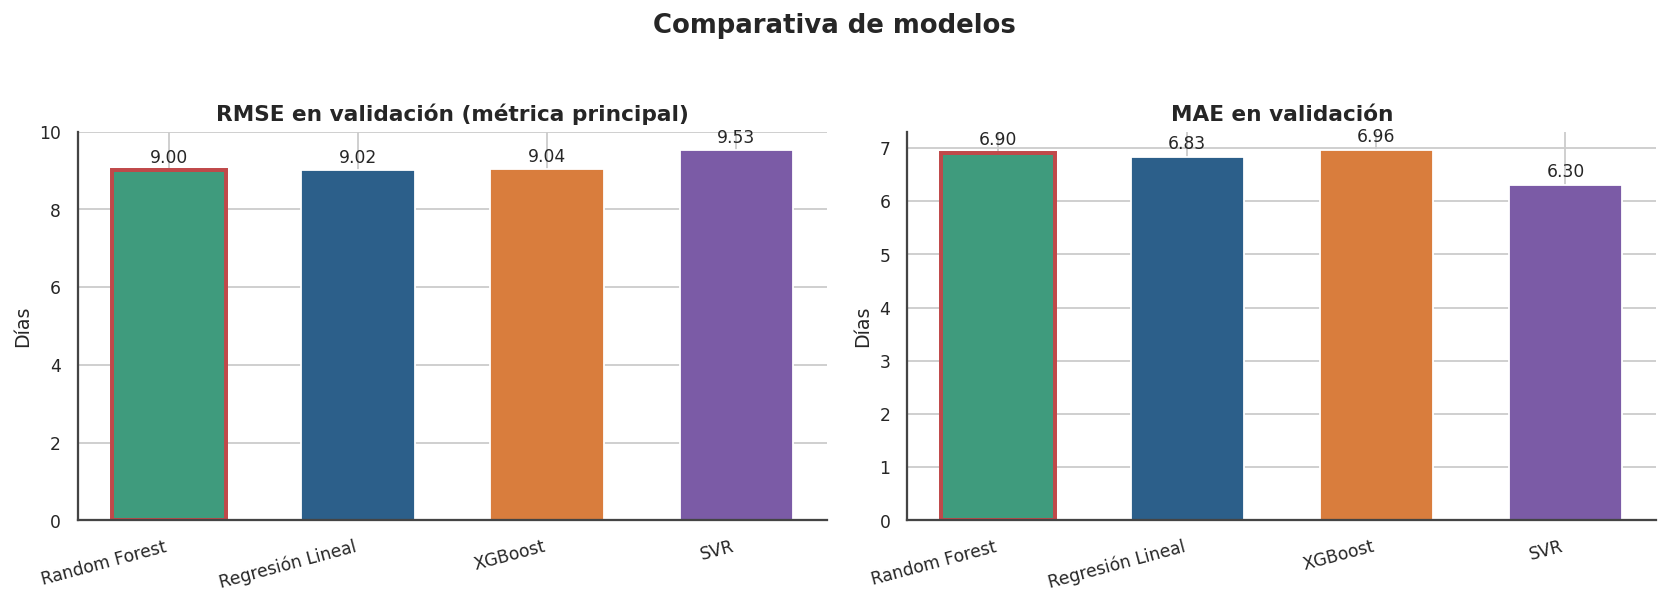

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
modelos_orden = df_res_val.sort_values('RMSE').index.tolist()
colores_mod = {'Regresión Lineal': PALETA['azul'], 'Random Forest': PALETA['verde'],
               'XGBoost': PALETA['naranja'], 'SVR': PALETA['morado']}

for ax, metrica, titulo in zip(axes, ['RMSE','MAE'],
                                ['RMSE en validación (métrica principal)','MAE en validación']):
    vals = [df_res_val.loc[m, metrica] for m in modelos_orden]
    cols = [colores_mod[m] for m in modelos_orden]
    bars = ax.bar(modelos_orden, vals, color=cols, edgecolor='white', width=0.6)
    bars[0].set_edgecolor(PALETA['rojo']); bars[0].set_linewidth(2.2)
    ax.set_title(titulo); ax.set_ylabel('Días')
    ax.set_xticklabels(modelos_orden, rotation=15, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.08, f'{v:.2f}',
                ha='center', va='bottom', fontsize=9.5)

plt.suptitle('Comparativa de modelos', fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/content/fig8_metricas.png', bbox_inches='tight', dpi=150)
plt.show()

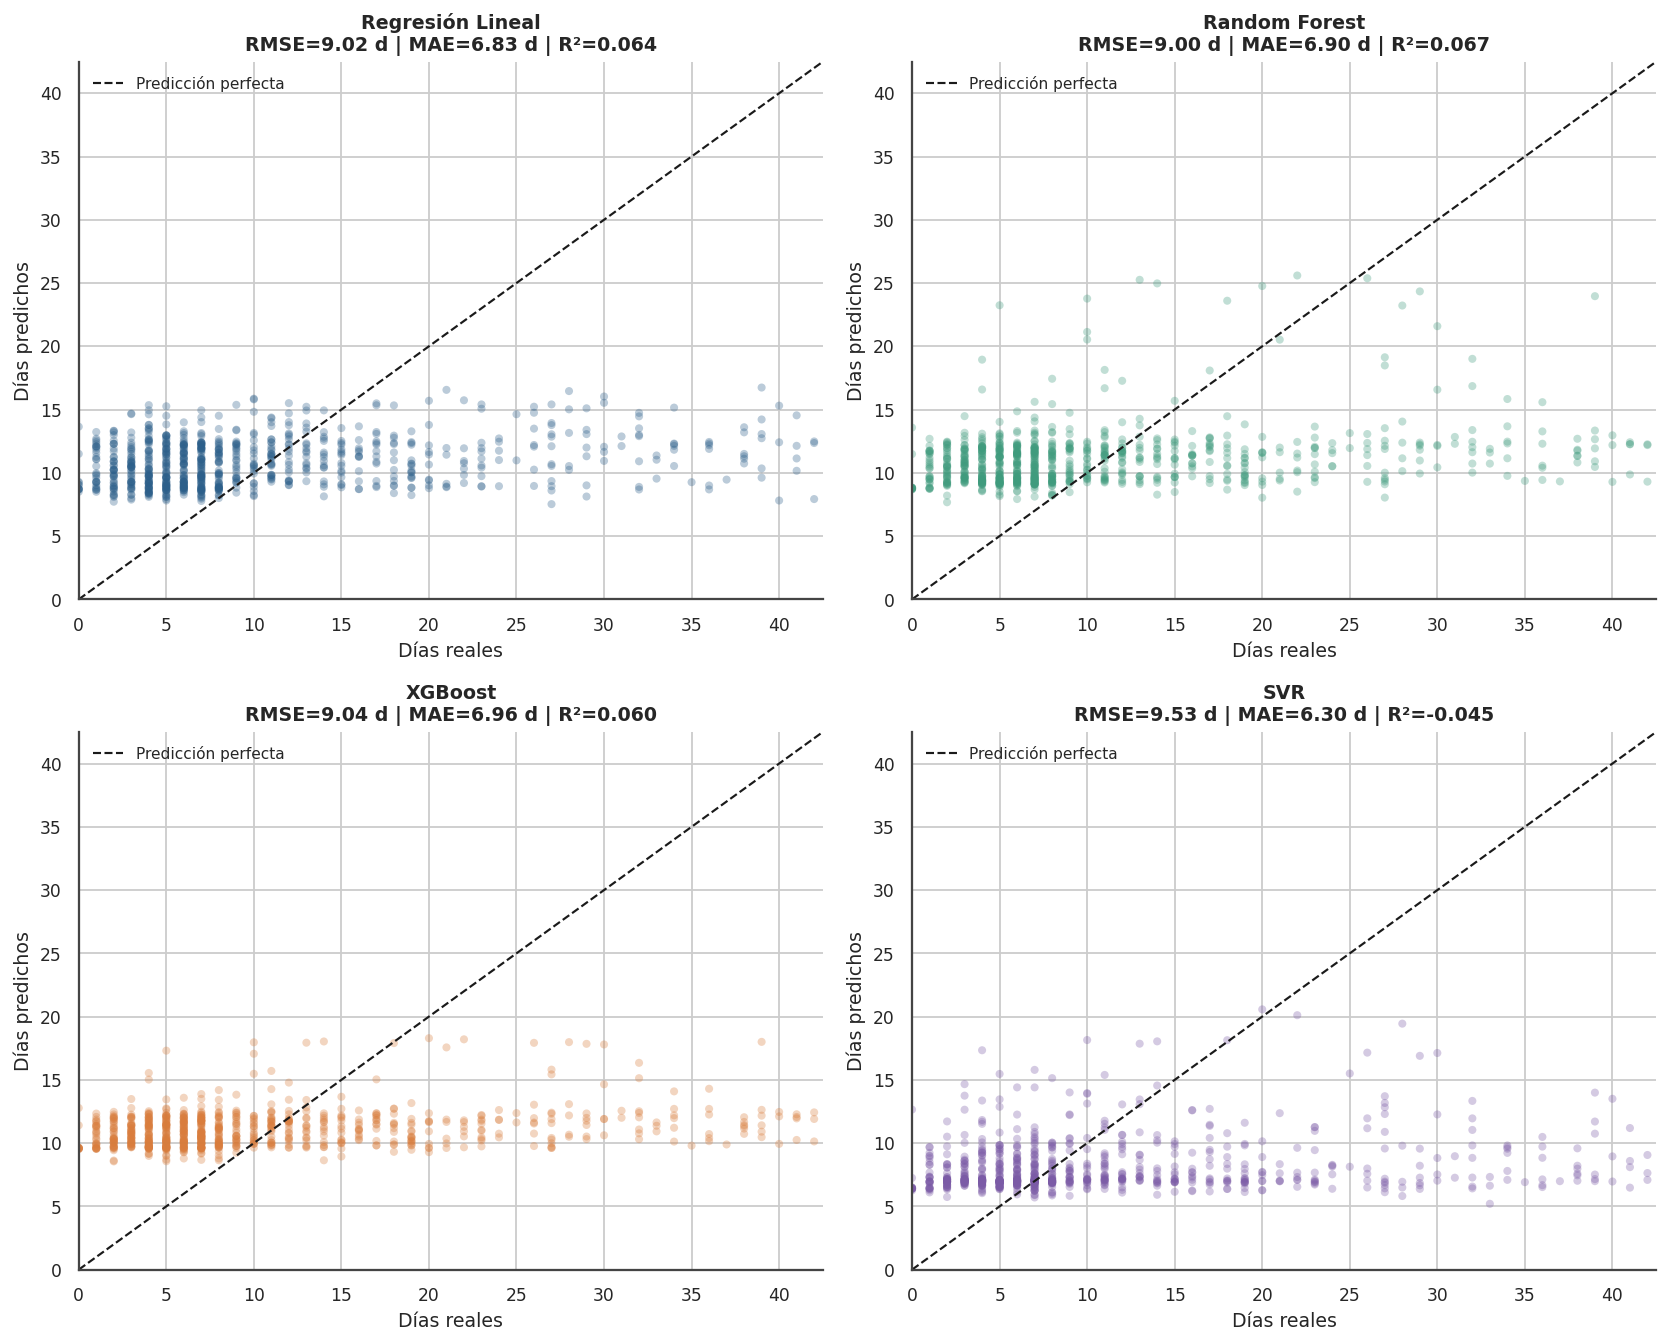

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10.5))
axes = axes.flatten()

for ax, nombre in zip(axes, ['Regresión Lineal','Random Forest','XGBoost','SVR']):
    y_pred = preds_val[nombre]
    yp_clip = np.clip(y_pred, 0, LIMITE_TUKEY)
    ax.scatter(y_val, yp_clip, alpha=0.32, color=colores_mod[nombre], s=20, edgecolor='none')
    ax.plot([0, LIMITE_TUKEY], [0, LIMITE_TUKEY], 'k--', linewidth=1.2, label='Predicción perfecta')
    m = metricas_reg(y_val, y_pred)
    ax.set_title(f'{nombre}\nRMSE={m["RMSE"]:.2f} d | MAE={m["MAE"]:.2f} d | R²={m["R²"]:.3f}', fontsize=10.5)
    ax.set_xlabel('Días reales'); ax.set_ylabel('Días predichos')
    ax.set_xlim(0, LIMITE_TUKEY); ax.set_ylim(0, LIMITE_TUKEY)
    ax.legend(fontsize=8.5, frameon=False)

#plt.suptitle('Predicciones vs. valores reales — validación ene-feb 2026 ', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/fig9_pred_vs_real.png', bbox_inches='tight', dpi=150)
plt.show()

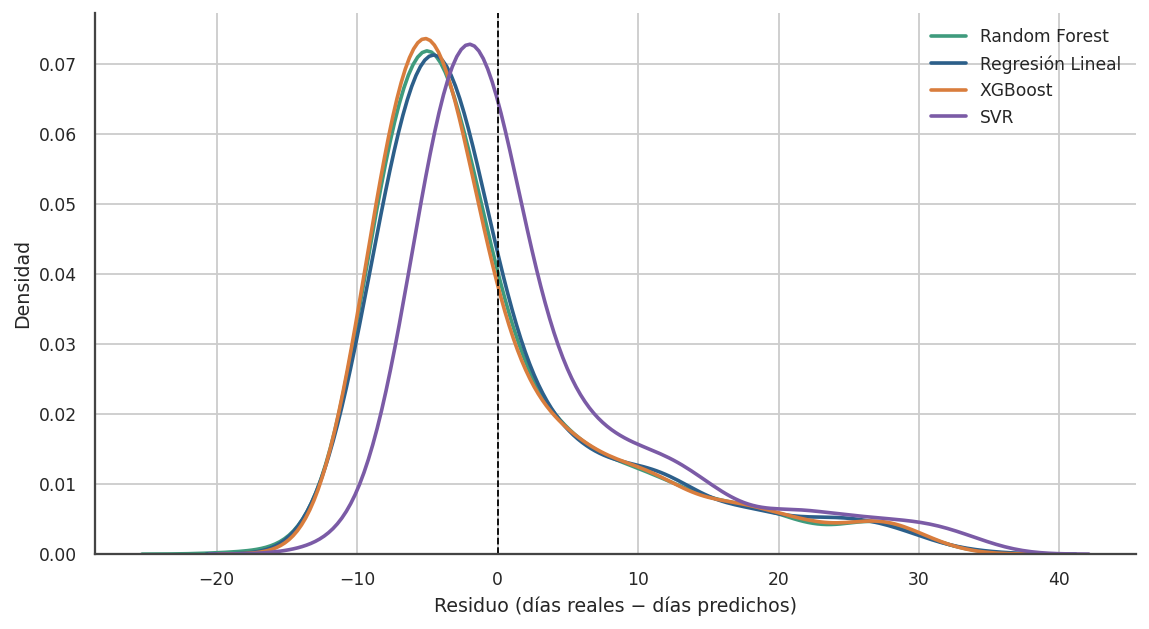

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for nombre in modelos_orden:
    residuos = y_val - preds_val[nombre]
    sns.kdeplot(residuos, ax=ax, label=nombre, color=colores_mod[nombre], linewidth=2)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
#ax.set_title('Distribución de residuos por modelo — Validación')
ax.set_xlabel('Residuo (días reales − días predichos)')
ax.set_ylabel('Densidad')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('/content/fig10_residuos.png', bbox_inches='tight', dpi=150)
plt.show()

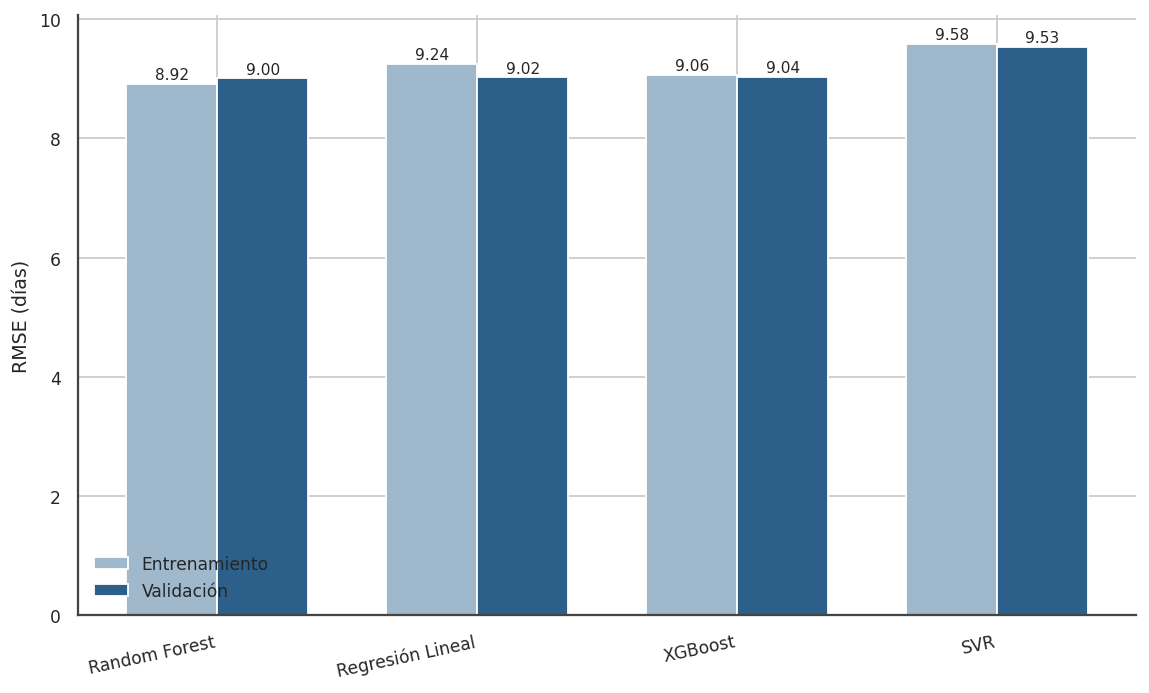

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
df_plot = pd.concat([
    df_res_train.assign(Partición='Entrenamiento'),
    df_res_val.assign(Partición='Validación')
]).reset_index()

x = np.arange(len(modelos_orden))
width = 0.35
rmse_train_vals = [df_res_train.loc[m, 'RMSE'] for m in modelos_orden]
rmse_val_vals   = [df_res_val.loc[m, 'RMSE'] for m in modelos_orden]

ax.bar(x - width/2, rmse_train_vals, width, label='Entrenamiento', color='#9FB8CC', edgecolor='white')
ax.bar(x + width/2, rmse_val_vals,   width, label='Validación',    color=PALETA['azul'], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(modelos_orden, rotation=12, ha='right')
ax.set_ylabel('RMSE (días)')
#ax.set_title('Generalización del modelo mediante RMSE (Entrenamiento vs. Validación) ')
ax.legend(frameon=False)
for i, (vt, vv) in enumerate(zip(rmse_train_vals, rmse_val_vals)):
    ax.text(i - width/2, vt + 0.08, f'{vt:.2f}', ha='center', fontsize=8.5)
    ax.text(i + width/2, vv + 0.08, f'{vv:.2f}', ha='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('/content/fig11_generalizacion.png', bbox_inches='tight', dpi=150)
plt.show()